### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/public_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/public_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [3]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [4]:
Industry_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Public Sector & Civil Society",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
print(len(Industry_chunks))
Industry_chunks.head(2)

11071


,chunk_uid,url,date,title,topic_v0,chunk_text
25,15_0_1_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",31,"In this bazaar scenario, most of the proxies t..."
26,15_0_1_0_1,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",31,This poses a major compliance risk. Taking all...


### Bertopic

In [6]:
# ! pip install bertopic

In [24]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small")  # , device="cuda"

umap_model = UMAP(
    n_neighbors=100, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=10, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=300, # smaller min_cluster_size will -> more detailed topics
    min_samples=100, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
docs = Industry_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [26]:
Industry_topics = topic_model.get_topic_info()
Industry_chunks_topics = Industry_chunks.assign( topic=topics,  probability=probs)

In [27]:
show_full(Industry_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[ai-powered face, including lack, tech reporter, assessing mitigating, migration border, use tackle, text said, concerns governments, having systems, island contributed]",35
1,0,"[schumer, bipartisan, newsom, majority leader, federal agencies, chuck, chuck schumer, leader chuck, senate majority, rounds]",3161
2,1,"[high-risk, european commission, fundamental rights, systems like, general purpose, negotiators, gpai, general-purpose, world-leading, intelligence rules]",2411
3,2,"[law firms, schwartz, legal research, legal professionals, citations, judicial, legal tech, litigation, bogus, legal teams]",1962
4,3,"[election commission, kramer, federal election, robocalls, ai-generated content, campaigning, election misinformation, synthetic, political campaigns, ai-generated images]",1299
5,4,"[bletchley, safety summit, bletchley park, sunak said, safety institute, donelan, taskforce, british prime, starmer, google deepmind]",1179
6,5,"[ont, calgary, alberta, quebec, rcmp, montreal, province, canadians, ctv, provincial]",682
7,6,"[guterres, secretary-general, guterres said, general assembly, peace security, international governance, governance artificial, antonio guterres, developing countries, woodward]",342


In [29]:
Industry_topics.to_csv(f"{DATA_DIR}/Public_specific/Industry_topics.csv", index=False)
Industry_chunks_topics.to_parquet(f"{DATA_DIR}/Public_specific/Industry_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [31]:
manual_related_topics = [0,1,2,3,4,6]
df_ai_impact = Industry_chunks_topics.loc[Industry_chunks_topics["topic"].isin(manual_related_topics)].copy()
print(len(df_ai_impact))

10354


In [32]:
df_ai_impact.to_parquet(f"{DATA_DIR}/Public_specific/public_df_ai_impact.parquet", index=False)

### Sentiment Analysis on chunk level

In [3]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Public_specific/public_df_ai_impact.parquet")

##### 1. use LLM to generate labels

In [7]:
df_ai_impact['topic'].value_counts()    

topic
0    3161
1    2411
2    1962
3    1299
4    1179
6     342
Name: count, dtype: int64

In [8]:
def topic_sample_n(topic_size):
    if topic_size >= 2000:
        return 150
    elif topic_size >= 1000:
        return 80
    else:
        return 30

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

570


C:\Users\ss363\AppData\Local\Temp\ipykernel_24736\418590217.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


topic
0    150
1    150
2     80
3     80
4     80
6     30
Name: count, dtype: int64

In [10]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [12]:
system_msg = """
You are an expert analyst of public sector and civil society institutions.

Your task is to evaluate how the public sector, civil society organizations,
and legal institutions described in the text are expected to be impacted by AI
or AI-related developments.

Public sector and civil society institutions include, but are not limited to:
- government agencies and regulators
- legislative bodies and public authorities
- courts and judicial institutions
- the legal profession and law firms
- election authorities and democratic institutions
- international organizations and multilateral bodies
- non-profit organizations and civil society groups
- public safety, governance, and administrative systems

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
   The text suggests that AI or related technologies are expected to benefit
   public institutions or civil society organizations.

   This may include:
   - improved public service efficiency
   - faster legal research or judicial processes
   - better regulatory monitoring or enforcement
   - enhanced government decision-making
   - improved election administration
   - better public safety or governance capacity
   - expanded institutional capabilities

2. "negatively"
   The text suggests that AI or related technologies are expected to harm,
   disrupt, or create risks for public institutions or civil society.

   This may include:
   - election misinformation or deepfakes
   - manipulation of political communication
   - regulatory or governance challenges
   - legal liability or judicial errors
   - erosion of public trust
   - institutional misuse of AI
   - surveillance or civil rights concerns
   - administrative disruption or systemic risk

3. "hard-to-say"
   The text is neutral, mixed, uncertain, speculative, descriptive without
   clear directional impact, or presents both benefits and risks without a
   clear dominant direction.

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- If the text discusses both pros and cons without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without clear directional
  judgment, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""

impact_user_template = """
Here is a text segment from the public sector and civil society domain:

{chunk_text}

Please determine whether the described industry or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [13]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [14]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [15]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
hard-to-say    335
positively     130
negatively     105
Name: count, dtype: int64

['41925_0_0_0_0', '89447_0_2_0_1', '132544_1_0_0_0', '77623_0_0_0_0', '93876_0_0_0_0', '132015_0_0_0_1', '129654_1_0_2_0', '115983_0_0_0_0', '132544_1_0_0_3', '76108_0_0_0_0', '47531_0_0_0_0', '103263_1_1_0_1', '53203_0_0_0_0', '96479_0_0_0_0', '42684_0_0_0_1', '73919_1_1_0_0', '143284_0_0_0_1', '77689_0_0_0_0', '134934_0_0_0_0', '77701_0_0_0_0', '77745_0_0_0_0', '73100_0_0_0_1', '77736_0_0_0_1', '77695_0_0_0_0', '12100_0_0_0_0', '34552_0_0_0_2', '77706_0_0_0_0', '77690_4_0_0_1', '77675_0_0_0_0', '30340_0_0_0_0', '126850_1_0_0_5', '13428_0_0_0_3', '6050_0_0_0_1', '146071_0_0_0_0', '77746_0_0_0_1', '77699_0_0_1_0', '75314_0_0_0_0', '88526_0_0_0_0', '23330_0_0_0_0', '2230_1_0_0_1', '51154_3_1_0_0', '65427_0_0_0_0', '23254_0_0_1_0', '3675_0_0_0_0', '63540_0_0_0_1', '24604_1_2_0_0', '138461_0_0_0_1', '2243_0_0_0_0', '63506_0_0_0_1', '140702_1_0_0_2', '82092_1_0_0_0', '117134_0_0_0_0', '43679_0_0_0_0', '86596_0_0_0_2', '24604_1_0_0_1', '41644_0_0_0_0', '120078_2_0_0_0', '140702_0_0_0_0', '4

lack negatively labeled samples, use llm api to generate some

In [17]:
df_train_ai_impact_label.to_parquet(f"{DATA_DIR}/Public_specific/public_ai_impact_train.parquet", index=False)

##### 2. finetune classifer

In [4]:
df_train_ai_impact_label = pd.read_parquet(f"{DATA_DIR}/Public_specific/public_ai_impact_train.parquet")
display(df_train_ai_impact_label['impact_label'].value_counts())

,count
impact_label,
hard-to-say,335
positively,130
negatively,105


In [5]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label.loc[df_train_ai_impact_label["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,Biden says tech companies must ensure AI produ...,1
1,Prabhakar explained that AI has an “uncountabl...,1
2,What is Biden's executive order on Artificial ...,1
3,"In writing the country’s most sweeping AI law,...",2
4,Tech executives urge Congress to regulate AI |...,1


In [6]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.15, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
1    285
2    110
0     89
Name: count, dtype: int64
label
1    50
2    20
0    16
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 484
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 86
    })
})

In [7]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 484
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 86
    })
})

In [9]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "public_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [10]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.839793,0.581395,0.245098,0.193798,0.333333
2,0.894349,0.657265,0.744186,0.679816,0.758771,0.652500
3,0.894349,0.580307,0.790698,0.733761,0.835979,0.703333
4,0.645128,0.567709,0.767442,0.743640,0.760392,0.730000
5,0.479077,0.529890,0.802326,0.777837,0.795788,0.764167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/public_models/public_ai_impact_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/public_models/public_ai_impact_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       0.87      0.81      0.84        16
 hard-to-say       0.81      0.88      0.85        50
  positively       0.71      0.60      0.65        20

    accuracy                           0.80        86
   macro avg       0.80      0.76      0.78        86
weighted avg       0.80      0.80      0.80        86



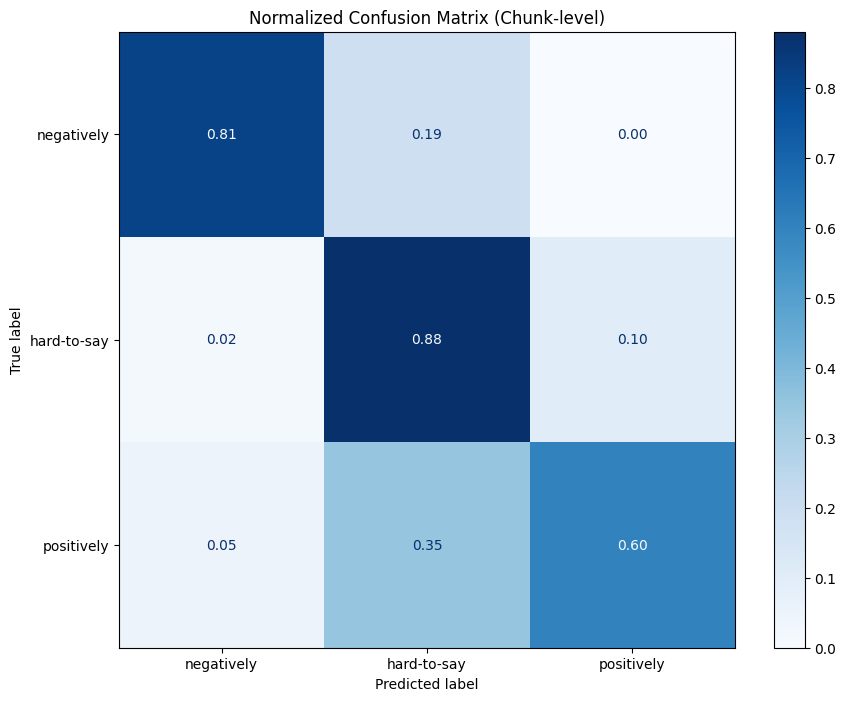

In [11]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [12]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Public_specific/public_df_ai_impact.parquet")
df_ai_impact.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,15_0_1_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",31,"In this bazaar scenario, most of the proxies t...",2,1.000000
1,15_0_1_0_1,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",31,This poses a major compliance risk. Taking all...,2,1.000000
2,110_0_0_0_0,https://www.medianama.com/2023/11/223-eu-ai-ov...,2023-11-24,"""Let’s Give AI in Europe a Fighting Chance"": E...",24,"""Let’s Give AI in Europe a Fighting Chance"": E...",1,0.844856
3,110_0_0_0_1,https://www.medianama.com/2023/11/223-eu-ai-ov...,2023-11-24,"""Let’s Give AI in Europe a Fighting Chance"": E...",24,Written By\nVallari Sanzgiri\nI'm interested i...,2,1.000000
4,125_0_0_0_0,https://www.ndtv.com/world-news/need-rules-for...,2025-02-11,"""Need Rules"" for AI development, Says French P...",106,"""Need Rules"" for AI development, Says French P...",1,0.417486


In [13]:
print(df_ai_impact.shape)

(10354, 8)


In [14]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/10354 [00:00<?, ? examples/s]

In [15]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(10354, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,15_0_1_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,"In this bazaar scenario, most of the proxies t...",positively,0.503607,0.198616,0.297777,0.503607
1,15_0_1_0_1,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,This poses a major compliance risk. Taking all...,positively,0.712313,0.079530,0.208157,0.712313
2,110_0_0_0_0,https://www.medianama.com/2023/11/223-eu-ai-ov...,2023-11-24,"""Let’s Give AI in Europe a Fighting Chance"": E...",1,"""Let’s Give AI in Europe a Fighting Chance"": E...",hard-to-say,0.870822,0.030564,0.870822,0.098614
3,110_0_0_0_1,https://www.medianama.com/2023/11/223-eu-ai-ov...,2023-11-24,"""Let’s Give AI in Europe a Fighting Chance"": E...",2,Written By\nVallari Sanzgiri\nI'm interested i...,hard-to-say,0.788460,0.043749,0.788460,0.167791
4,125_0_0_0_0,https://www.ndtv.com/world-news/need-rules-for...,2025-02-11,"""Need Rules"" for AI development, Says French P...",1,"""Need Rules"" for AI development, Says French P...",hard-to-say,0.906502,0.046338,0.906502,0.047160


/tmp/ipykernel_12387/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


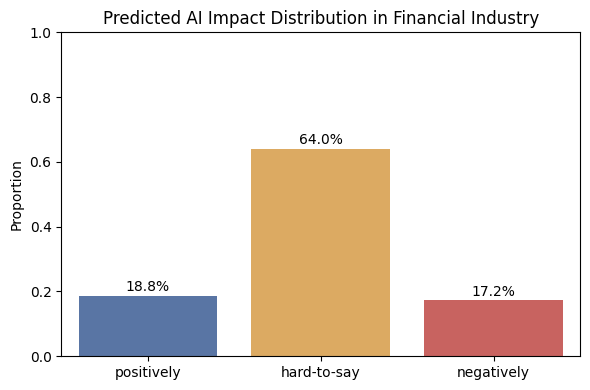

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
df_ai_impact_pred.to_parquet(f"{model_dir}/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [3]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/public_ai_impact_classifier_predictions.parquet")
df_ai_impact_pred.head(2)

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,15_0_1_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,"In this bazaar scenario, most of the proxies t...",positively,0.503607,0.198616,0.297777,0.503607
1,15_0_1_0_1,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,This poses a major compliance risk. Taking all...,positively,0.712313,0.079530,0.208157,0.712313


#### Positive impact

In [6]:
df_ai_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(500, random_state=38).reset_index(drop=True)

In [5]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [7]:
entity_system_msg = """\
You are an information extraction system for public sector and civil society-related news articles.

The user will provide a text block from a news article related to public institutions,
government, law, or civil society.

Your task is to extract only the following:

1. organizations or institutions in the public sector, legal system, or civil society explicitly mentioned in the text
2. AI-related technologies, capabilities, or impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named organizations or institutions explicitly stated in the text.

These may include:

- government agencies
- legislative bodies
- courts and judicial institutions
- law firms and legal organizations
- election authorities
- regulatory bodies
- international organizations
- non-profit organizations
- civil society groups
- public safety institutions
- policy institutions or think tanks


Examples:

- U.S. Senate
- European Commission
- Federal Election Commission
- U.S. Department of Homeland Security
- U.S. Supreme Court
- United Nations
- OpenAI
- Google DeepMind
- Bletchley Park AI Safety Institute
- American Civil Liberties Union
- Amnesty International
- International Monetary Fund


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract AI-related technologies or public-sector impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:

AI technologies:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- synthetic media
- deepfake technology

Public-sector impact mechanisms:
- regulatory oversight
- policy enforcement
- legal research automation
- judicial decision support
- election monitoring
- misinformation detection
- public service automation
- administrative efficiency
- government surveillance
- compliance monitoring
- governance risk
- institutional accountability
- public trust


## Directions

- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the government”, “the agency”, “officials”, or “authorities”
  unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [8]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [9]:
train_ai_impact_ner = []

for idx, row in df_ai_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_impact_ner.append(result)
    
df_ai_impact_ner_result = pd.DataFrame(train_ai_impact_ner)

In [11]:
df_ai_impact_ner_result.to_parquet(f"{DATA_DIR}/Public_specific/public_ai_impact_ner.parquet", index=False)

##### Organization 

In [12]:
df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Public_specific/public_ai_impact_ner.parquet")

In [13]:
df_posorg_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(954, 2)
(188, 2)


,entity_raw,raw_count
0,OpenAI,37
1,Microsoft,24
2,White House,18
3,Anthropic,16
4,Google,13
...,...,...
183,WilmerHale,2
184,AI Safety Summit,2
185,William Fry,2
186,ABA Surveying,2


In [14]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

'- (OpenAI, 37)\n- (Microsoft, 24)\n- (White House, 18)\n- (Anthropic, 16)\n- (Google, 13)\n- (European Union, 13)\n- (UK government, 13)\n- (Congress, 10)\n- (Thomson Reuters, 9)\n- (Supreme Court, 9)\n- (Meta, 9)\n- (UK Government, 9)\n- (LexisNexis, 8)\n- (CISA, 8)\n- (Department of Homeland Security, 8)\n- (GSA, 8)\n- (Gray Media Group, 7)\n- (DHS, 7)\n- (Casetext, 7)\n- (National Institute of Standards and Technology, 6)\n- (Google DeepMind, 6)\n- (IBM, 6)\n- (State Department, 5)\n- (AWS, 5)\n- (National Science Foundation, 5)\n- (Office of Management and Budget, 5)\n- (Law360 Pulse, 5)\n- (Nvidia, 5)\n- (Federal News Network, 5)\n- (EU, 5)\n- (General Services Administration, 5)\n- (Department of State, 4)\n- (OMB, 4)\n- (European Commission, 4)\n- (Google Cloud, 4)\n- (EvenUp, 4)\n- (Foundation Model Taskforce, 4)\n- (Department of Commerce, 4)\n- (White House Office of Science and Technology Policy, 4)\n- (Icertis, 4)\n- (UK, 4)\n- (U.S. Department of Homeland Security, 4)\n- 

In [21]:
org_top_system_msg = """\
You are an organization name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted
from public sector and civil society AI-related news.

Your tasks:

1. Merge raw names that clearly refer to the same organization into one canonical organization name.
2. Classify canonical organizations into:
   - public_institution
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 public sector or civil society institutions
   - Top 10 AI companies

   
Definitions:

### public_institution
Organizations primarily operating in the public sector, governance, legal system,
international institutions, or civil society.

Examples include:
- government agencies
- legislative bodies
- courts or judicial institutions
- regulatory authorities
- election commissions
- international organizations
- non-profit or civil society organizations
- policy institutions or public research bodies


### ai_company
Companies primarily focused on AI technologies, AI infrastructure,
or major technology companies involved in AI development.


Rules:
- Be conservative when merging.
- Do not merge different companies.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "public_sector_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "public_sector_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["public_sector_top10", "ai_top10"],
    "additionalProperties": False
}

In [22]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [24]:
industry_company_top10_pos = pd.DataFrame(result_posorg["public_sector_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Public Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Public Top 10


,canonical_name,total_count,source_raw_names
0,UK government,27,"[UK government, UK Government, British governm..."
1,White House,22,"[White House, White House Office of Science an..."
2,European Union,18,"[European Union, EU, European Commission]"
3,Department of Homeland Security,17,"[Department of Homeland Security, DHS, U.S. De..."
4,Congress,12,"[Congress, U.S. Congress]"
5,General Services Administration,13,"[GSA, General Services Administration]"
6,State Department,9,"[State Department, Department of State, Depart..."
7,Office of Management and Budget,9,"[Office of Management and Budget, OMB]"
8,National Institute of Standards and Technology,8,[National Institute of Standards and Technolog...
9,National Science Foundation,8,"[National Science Foundation, NSF]"


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,39,"[OpenAI, Open AI]"
1,Microsoft,24,[Microsoft]
2,Anthropic,16,[Anthropic]
3,Google,23,"[Google, Google DeepMind, Google Cloud, Alphabet]"
4,Meta,9,[Meta]
5,IBM,6,[IBM]
6,Amazon,13,"[Amazon, Amazon Web Services, AWS]"
7,Nvidia,7,"[Nvidia, NVIDIA]"
8,Palantir,4,[Palantir]
9,Salesforce,2,[Salesforce]


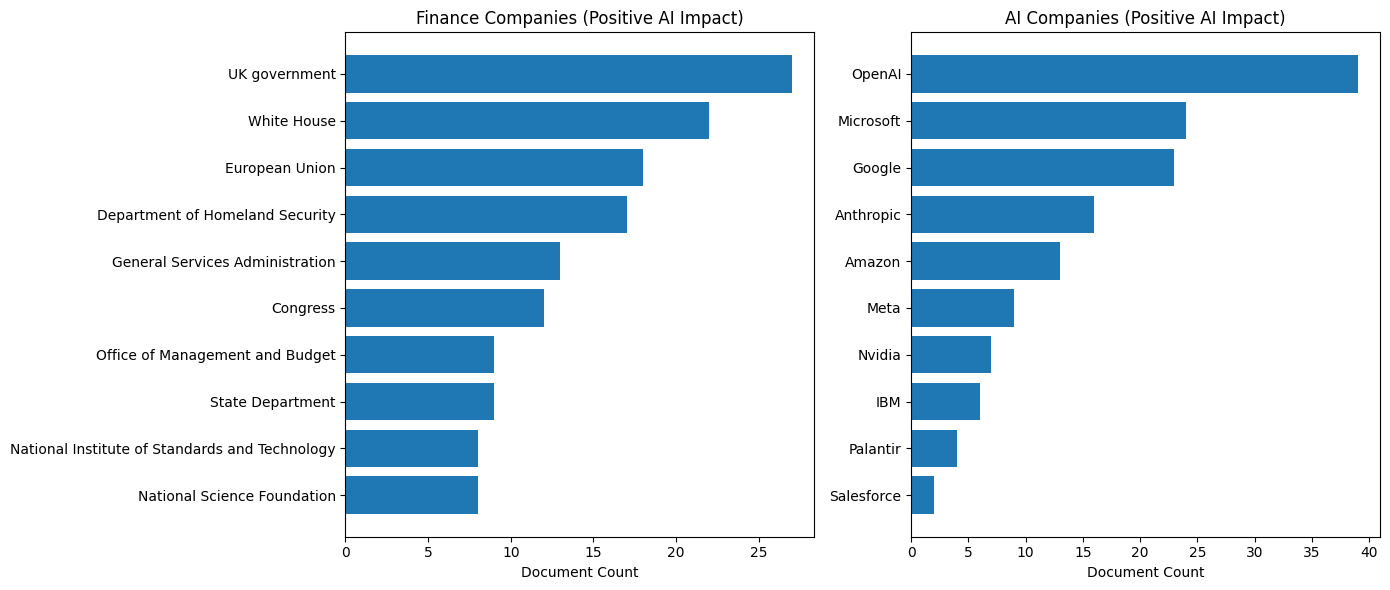

In [25]:
import matplotlib.pyplot as plt
import numpy as np

public_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("public Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [26]:
df_posmech_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(1168, 2)
(212, 2)


,entity_raw,raw_count
0,generative AI,133
1,artificial intelligence,99
2,legal research automation,84
3,AI,76
4,administrative efficiency,61
...,...,...
207,AI Action Plan,2
208,AI Citator,2
209,translation,2
210,AI Growth Zones,2


In [27]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (generative AI, 133)\n- (artificial intelligence, 99)\n- (legal research automation, 84)\n- (AI, 76)\n- (administrative efficiency, 61)\n- (regulatory oversight, 48)\n- (machine learning, 46)\n- (public trust, 43)\n- (compliance monitoring, 41)\n- (large language models, 41)\n- (policy enforcement, 38)\n- (institutional accountability, 37)\n- (governance risk, 34)\n- (AI tools, 31)\n- (judicial decision support, 28)\n- (public service automation, 28)\n- (predictive analytics, 27)\n- (natural language processing, 23)\n- (AI safety, 22)\n- (AI systems, 21)\n- (artificial intelligence (AI), 18)\n- (AI technology, 16)\n- (AI models, 15)\n- (AI governance, 14)\n- (ChatGPT, 13)\n- (AI technologies, 13)\n- (Artificial Intelligence, 12)\n- (AI adoption, 11)\n- (government surveillance, 11)\n- (transparency, 10)\n- (legal research, 9)\n- (automation, 9)\n- (document review, 9)\n- (AI development, 9)\n- (cybersecurity, 8)\n- (AI innovation, 8)\n- (generative artificial intelligence, 8)\n- (mi

In [28]:
posmech_top_system_msg = """\
You are an AI technology and public sector impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from public sector and civil society AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_public_sector_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI public sector positive impact mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing
- synthetic media

### ai_public_sector_mechanism
Applications, institutional capabilities, or operational mechanisms through which AI
positively affects the public sector, legal systems, governance institutions, or civil society.

Examples:
- public service automation
- administrative efficiency
- productivity improvement
- workflow automation
- legal research support
- judicial process support
- regulatory monitoring
- compliance monitoring
- public safety coordination
- election monitoring
- misinformation detection


### other
Anything vague, unclear, or not clearly an AI technology or public-sector mechanism.

Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- Only classify items as ai_public_sector_mechanism when the public-sector, legal, governance,
  or civil society context is clear.
- machine learning, deep learning, and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""



mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [29]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [30]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,143,"[generative AI, generative artificial intellig..."
1,artificial intelligence,205,"[artificial intelligence, AI, artificial intel..."
2,machine learning,50,"[machine learning, deep learning, Machine Lear..."
3,large language models,58,"[large language models, ChatGPT, LLMs, GPT-4, ..."
4,predictive analytics,27,[predictive analytics]
5,natural language processing,27,"[natural language processing, Natural Language..."
6,computer vision,4,[computer vision]
7,synthetic media,10,"[synthetic media, deepfake technology]"
8,foundation models,7,"[foundation models, foundational models, gener..."
9,explainable AI,2,[explainable AI (XAI)]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,legal research automation,93,"[legal research automation, legal research, le..."
1,administrative efficiency,61,[administrative efficiency]
2,regulatory oversight,48,[regulatory oversight]
3,compliance monitoring,47,"[compliance monitoring, regulatory compliance,..."
4,policy enforcement,38,[policy enforcement]
5,judicial decision support,28,[judicial decision support]
6,public service automation,28,[public service automation]
7,misinformation detection,7,[misinformation detection]
8,election monitoring,5,[election monitoring]
9,workflow automation,7,"[workflow automation, automation, intelligent ..."


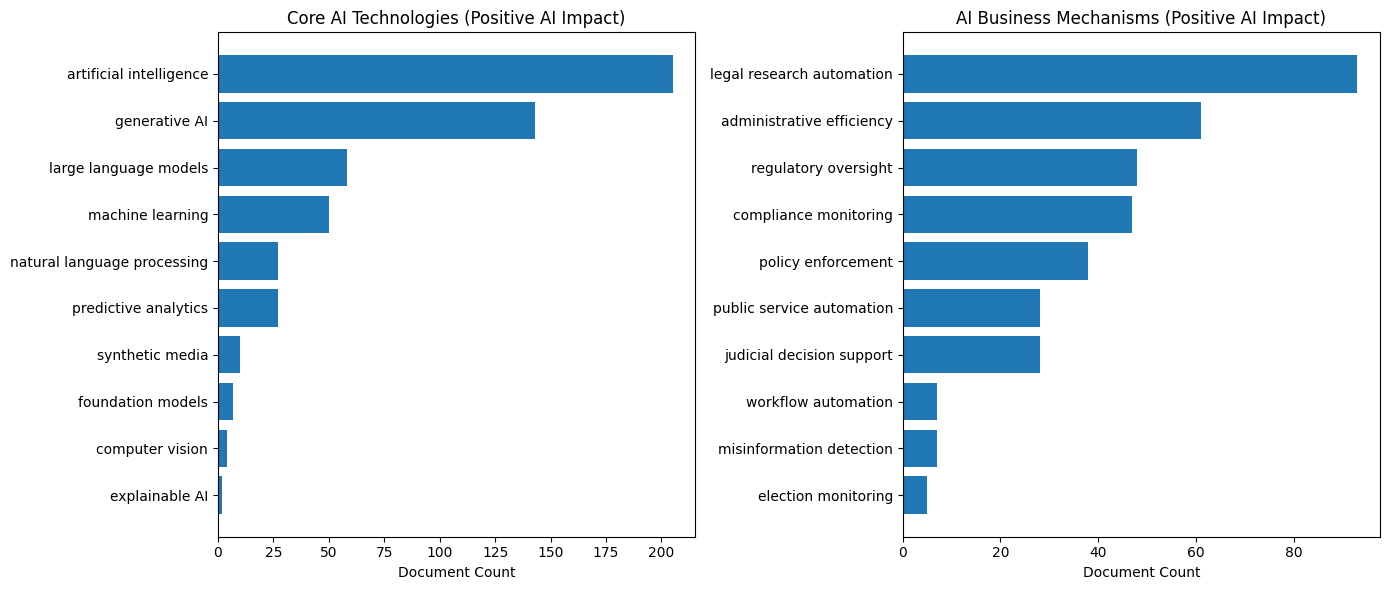

In [31]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [33]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].sample(500, random_state=43).reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

500


In [35]:
neg_entity_system_msg = """\
You are an information extraction system for public sector and civil society-related news articles.

The user will provide a text block from a news article related to public institutions,
government, law, or civil society.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or institutions in the public sector, legal system, or civil society explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named organizations or institutions explicitly stated in the text.

These may include:
- government agencies
- legislative bodies
- courts and judicial institutions
- law firms and legal organizations
- election authorities
- regulatory bodies
- international organizations
- non-profit organizations
- civil society groups
- public safety institutions
- policy institutions or think tanks

Examples:
- U.S. Senate
- European Commission
- Federal Election Commission
- U.S. Department of Homeland Security
- U.S. Supreme Court
- United Nations
- OpenAI
- Google DeepMind
- AI Safety Institute
- American Civil Liberties Union
- Amnesty International
- International Monetary Fund

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:
- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE public-sector, legal, governance, or civil-society impact mechanisms explicitly mentioned in the text

Examples of technologies / capabilities:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- synthetic media
- deepfake technology
- facial recognition

Examples of NEGATIVE impact mechanisms:
- election misinformation
- deepfake political ads
- robocall deception
- legal hallucinations
- judicial errors
- unsafe legal advice
- regulatory gaps
- governance failures
- surveillance concerns
- civil rights violations
- privacy violations
- public trust erosion
- institutional misuse
- compliance failures
- policy manipulation
- disinformation
- administrative disruption
- systemic risk
- bias in public decision-making

## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the government”, “the agency”, “officials”, “authorities”,
  “the court”, or “lawmakers” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [36]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

[Row 2] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}
[Row 207] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}
[Row 218] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}
[Row 447] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


In [37]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Public_specific/public_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [38]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(648, 2)
(193, 2)


,entity_raw,raw_count
0,OpenAI,99
1,Meta,51
2,Google,50
3,Microsoft,47
4,Republican National Committee,28
...,...,...
188,WhatsApp,2
189,AP,2
190,Washington Post,2
191,ABC News,2


In [39]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (OpenAI, 99)\n- (Meta, 51)\n- (Google, 50)\n- (Microsoft, 47)\n- (Republican National Committee, 28)\n- (X, 26)\n- (Federal Election Commission, 26)\n- (Congress, 26)\n- (Facebook, 19)\n- (Associated Press, 19)\n- (Avianca, 16)\n- (Public Citizen, 16)\n- (YouTube, 15)\n- (Levidow, Levidow & Oberman, 15)\n- (Manhattan federal court, 13)\n- (TikTok, 13)\n- (European Union, 13)\n- (The Associated Press, 12)\n- (Adobe, 11)\n- (U.S. District Court, 11)\n- (Higher Ground Labs, 10)\n- (Reuters, 9)\n- (National Association of Secretaries of State, 9)\n- (Amazon, 9)\n- (Twitter, 9)\n- (Federal Communications Commission, 9)\n- (University of Chicago Harris School of Public Policy, 8)\n- (FCC, 8)\n- (The Associated Press-NORC Center for Public Affairs Research, 8)\n- (Instagram, 8)\n- (CNN, 8)\n- (Munich Security Conference, 8)\n- (Biden campaign, 7)\n- (Cambridge Analytica, 7)\n- (FBI, 7)\n- (Midjourney, 7)\n- (SOS America PAC, 7)\n- (Coalition for Content Provenance and Authenticity, 6)\n- (

In [40]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [41]:
industry_company_top10_neg = pd.DataFrame(result_negorg["public_sector_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("public Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

public Top 10


,canonical_name,total_count,source_raw_names
0,Congress,28,"[Congress, Senate, House, U.S. Senate, U.S. Ho..."
1,Federal Election Commission,29,"[Federal Election Commission, FEC]"
2,Republican National Committee,34,"[Republican National Committee, RNC]"
3,European Union,17,"[European Union, EU, European Parliament, Euro..."
4,Federal Communications Commission,17,"[Federal Communications Commission, FCC]"
5,Democratic National Committee,6,"[Democratic National Committee, DNC]"
6,White House,5,[White House]
7,Election Commission of India,5,[Election Commission of India]
8,National Association of Secretaries of State,9,[National Association of Secretaries of State]
9,World Economic Forum,6,[World Economic Forum]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,99,[OpenAI]
1,Meta,70,"[Meta, Facebook, Instagram, Threads, WhatsApp]"
2,Google,65,"[Google, YouTube]"
3,Microsoft,49,"[Microsoft, Microsoft Bing]"
4,X,35,"[X, Twitter]"
5,Amazon,9,[Amazon]
6,Adobe,11,[Adobe]
7,TikTok,13,[TikTok]
8,Anthropic,6,[Anthropic]
9,Midjourney,7,[Midjourney]


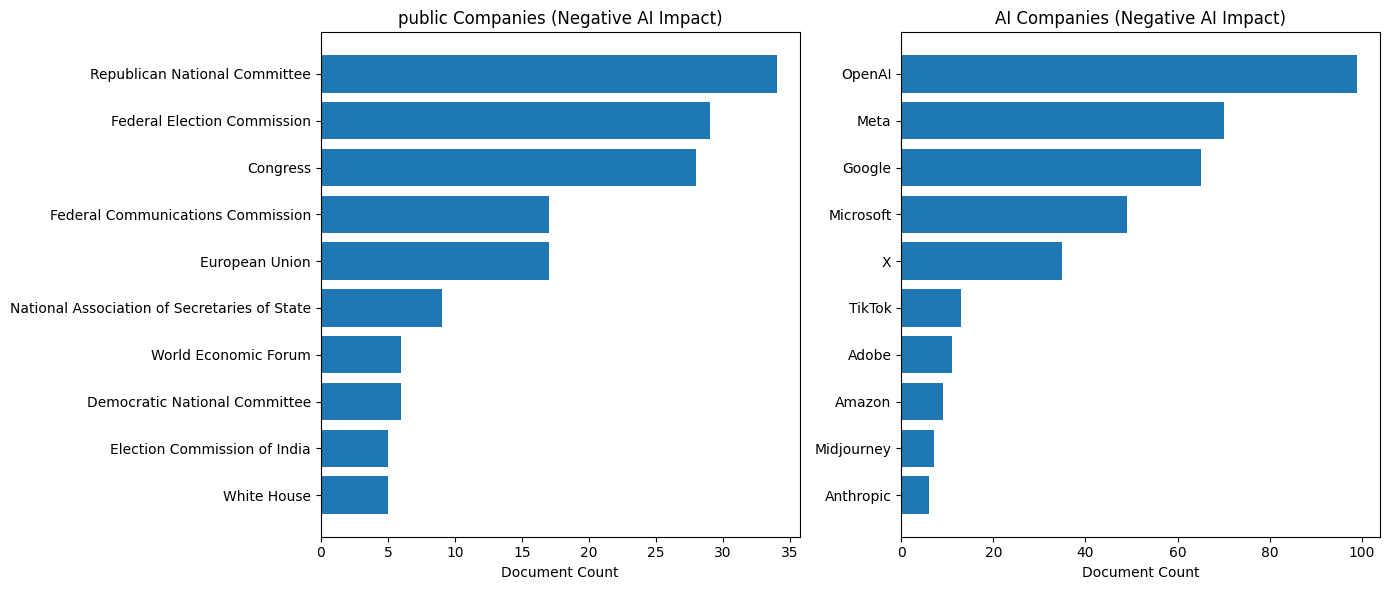

In [45]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("public Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [43]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(1171, 2)
(281, 2)


,entity_raw,raw_count
0,election misinformation,135
1,generative AI,101
2,ChatGPT,100
3,legal hallucinations,84
4,artificial intelligence,79
...,...,...
276,trick voters,2
277,unfairly sway an election,2
278,violation of duty to provide competent represe...,2
279,videos and audio clips,2


In [44]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (election misinformation, 135)\n- (generative AI, 101)\n- (ChatGPT, 100)\n- (legal hallucinations, 84)\n- (artificial intelligence, 79)\n- (deepfakes, 77)\n- (disinformation, 67)\n- (unsafe legal advice, 59)\n- (public trust erosion, 56)\n- (judicial errors, 52)\n- (AI, 41)\n- (AI-generated images, 41)\n- (AI-generated content, 39)\n- (misinformation, 37)\n- (deepfake political ads, 32)\n- (AI tools, 25)\n- (generative AI tools, 23)\n- (generative artificial intelligence, 22)\n- (robocall deception, 22)\n- (AI-generated deepfakes, 21)\n- (AI deepfakes, 20)\n- (compliance failures, 20)\n- (election disinformation, 20)\n- (artificial intelligence-powered chatbot, 17)\n- (large language models, 16)\n- (AI-generated audio, 15)\n- (AI chatbot, 15)\n- (AI-generated ad, 14)\n- (artificial intelligence tools, 14)\n- (AI chatbots, 14)\n- (mislead voters, 13)\n- (regulatory gaps, 12)\n- (AI models, 12)\n- (deepfake, 11)\n- (robocalls, 10)\n- (institutional misuse, 9)\n- (deepfake technology, 

In [46]:
neg_mech_top_system_msg = """\
You are an AI technology and public sector impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from public sector and civil society AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_public_sector_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI public sector negative impact mechanisms


Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.


### ai_public_sector_mechanism
Governance, legal, regulatory, democratic, or institutional mechanisms
through which AI negatively affects the public sector, legal systems,
or civil society.



### other
Anything vague, unclear, or not clearly technology or mechanism.


Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- Only classify items as ai_public_sector_mechanism when the governance,
  legal, regulatory, or civil society context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

In [47]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [48]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,generative AI,149,"[generative AI, generative artificial intellig..."
1,large language models,126,"[ChatGPT, large language models, LLMs, languag..."
2,deepfakes,124,"[deepfakes, deepfake, deepfake technology, dee..."
3,AI-generated content,122,"[AI-generated images, AI-generated content, AI..."
4,artificial intelligence,120,"[artificial intelligence, AI, Artificial Intel..."
5,AI tools,73,"[AI tools, generative AI tools, artificial int..."
6,machine learning,4,[machine learning]
7,algorithms,6,[algorithms]
8,synthetic media,13,"[synthetic content, synthetic media, synthetic..."
9,hallucinations,14,"[hallucinations, hallucinate, hallucination]"


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,election misinformation/disinformation,227,"[election misinformation, disinformation, misi..."
1,legal hallucinations/errors,98,"[legal hallucinations, unsafe legal advice, ju..."
2,public trust erosion,58,"[public trust erosion, erode trust, crisis of ..."
3,compliance failures,20,[compliance failures]
4,regulatory gaps,12,[regulatory gaps]
5,institutional misuse,9,[institutional misuse]
6,systemic risk,5,[systemic risk]
7,bias in public decision-making,6,[bias in public decision-making]
8,administrative disruption,6,[administrative disruption]
9,governance failures,3,[governance failures]


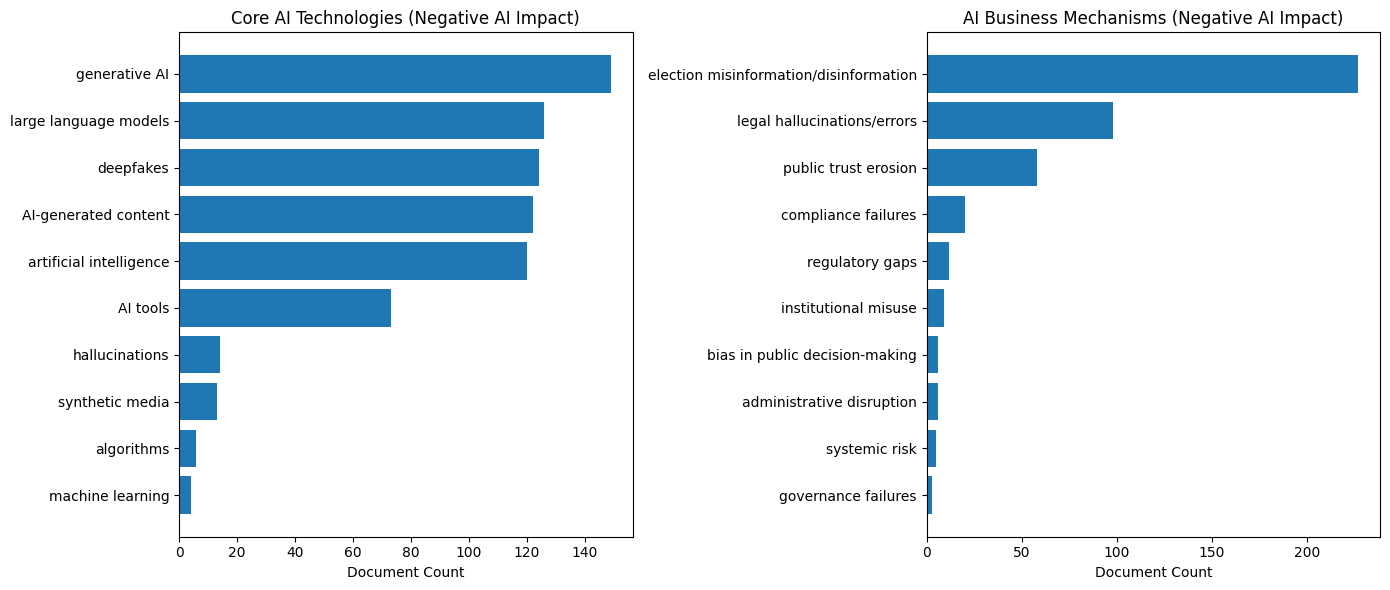

In [49]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [50]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/public_ai_impact_classifier_predictions.parquet")

#### Topic Aggregation

In [51]:
Industry_topics = pd.read_csv(f"{DATA_DIR}/Public_specific/Industry_topics.csv")
Industry_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Public_specific/Industry_chunks_topics.parquet")

In [52]:
display(Industry_topics)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,35,-1_ai-powered face_including lack_tech reporte...,"['ai-powered face', 'including lack', 'tech re...",['The companies building foundation models wil...
1,0,3161,0_schumer_bipartisan_newsom_majority leader,"['schumer', 'bipartisan', 'newsom', 'majority ...","[""In closed forum, tech titans to give senator..."
2,1,2411,1_high-risk_european commission_fundamental ri...,"['high-risk', 'european commission', 'fundamen...",['How do they work and will they affect people...
3,2,1962,2_law firms_schwartz_legal research_legal prof...,"['law firms', 'schwartz', 'legal research', 'l...","['10th Circ. Ends Civil Rights Suit, Sanctions..."
4,3,1299,3_election commission_kramer_federal election_...,"['election commission', 'kramer', 'federal ele...",['The Federal Election Commission has begun a ...
5,4,1179,4_bletchley_safety summit_bletchley park_sunak...,"['bletchley', 'safety summit', 'bletchley park...",['Sunak says agreements at UK summit tip the b...
6,5,682,5_ont_calgary_alberta_quebec,"['ont', 'calgary', 'alberta', 'quebec', 'rcmp'...","[""B.C. premier sees promise in AI | CTV News\n..."
7,6,342,6_guterres_secretary-general_guterres said_gen...,"['guterres', 'secretary-general', 'guterres sa...",['UN chief appoints 39-member panel to advise ...


##### AI Impact

In [53]:
ai_impact_topic_id = [0,1,2,3,4,6]
ai_impact_topics = Industry_topics[Industry_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
1,0,"['schumer', 'bipartisan', 'newsom', 'majority ...","[""In closed forum, tech titans to give senator..."
2,1,"['high-risk', 'european commission', 'fundamen...",['How do they work and will they affect people...
3,2,"['law firms', 'schwartz', 'legal research', 'l...","['10th Circ. Ends Civil Rights Suit, Sanctions..."
4,3,"['election commission', 'kramer', 'federal ele...",['The Federal Election Commission has begun a ...
5,4,"['bletchley', 'safety summit', 'bletchley park...",['Sunak says agreements at UK summit tip the b...
7,6,"['guterres', 'secretary-general', 'guterres sa...",['UN chief appoints 39-member panel to advise ...


In [54]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in ai_impact_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

ai_impact_topics["topic_summary"] = summaries
show_full(ai_impact_topics[["Topic", "topic_summary"]])

,Topic,topic_summary
1,0,Senate Majority Leader Chuck Schumer is leading bipartisan efforts to craft legislation regulating artificial intelligence.
2,1,The European Union's new AI regulations focus on managing high-risk systems and protecting fundamental rights.
3,2,This topic is about legal technology and AI tools transforming legal research and practice for law firms.
4,3,The Federal Election Commission is considering regulating AI-generated deepfakes in political campaign ads to combat election misinformation.
5,4,The UK's AI Safety Summit at Bletchley Park focused on international cooperation to manage AI risks.
7,6,UN Secretary-General Guterres appoints a panel to advise on global AI governance.


In [55]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,15_0_1_0_0,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,"In this bazaar scenario, most of the proxies t...",positively,0.503607,0.198616,0.297777,0.503607,15
1,15_0_1_0_1,https://www.mexc.com/kk-KZ/news/1093,2025-09-10,"""Bazaar"" surpasses ""Cathedral"", how does crypt...",2,This poses a major compliance risk. Taking all...,positively,0.712313,0.079530,0.208157,0.712313,15


In [56]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,0,1583,77,251
1,1,1072,15,84
2,2,185,238,599
3,3,65,614,16
4,4,602,6,124
5,6,248,2,6


pred_label,topic,hard-to-say,negatively,positively
0,0,82.84%,4.03%,13.13%
1,1,91.55%,1.28%,7.17%
2,2,18.1%,23.29%,58.61%
3,3,9.35%,88.35%,2.3%
4,4,82.24%,0.82%,16.94%
5,6,96.88%,0.78%,2.34%


In [57]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,0,0.828362,0.040293,0.131345,0.091052
1,1,0.915457,0.012810,0.071734,0.058924
2,2,0.181018,0.232877,0.586106,0.353229
3,3,0.093525,0.883453,0.023022,-0.860432
4,4,0.822404,0.008197,0.169399,0.161202
5,6,0.968750,0.007812,0.023438,0.015625


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [58]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.81, 0.19, 0.00],
    [0.02, 0.88, 0.10],
    [0.05, 0.35, 0.60]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,0,0.909553,0.023131,0.067316,0.044185
1,1,1.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.187515,0.812485,0.624970
3,3,0.000000,0.939716,0.060284,-0.879431
4,4,0.867865,0.000000,0.132135,0.132135
5,6,1.000000,0.000000,0.000000,0.000000


#### Time Aggregation

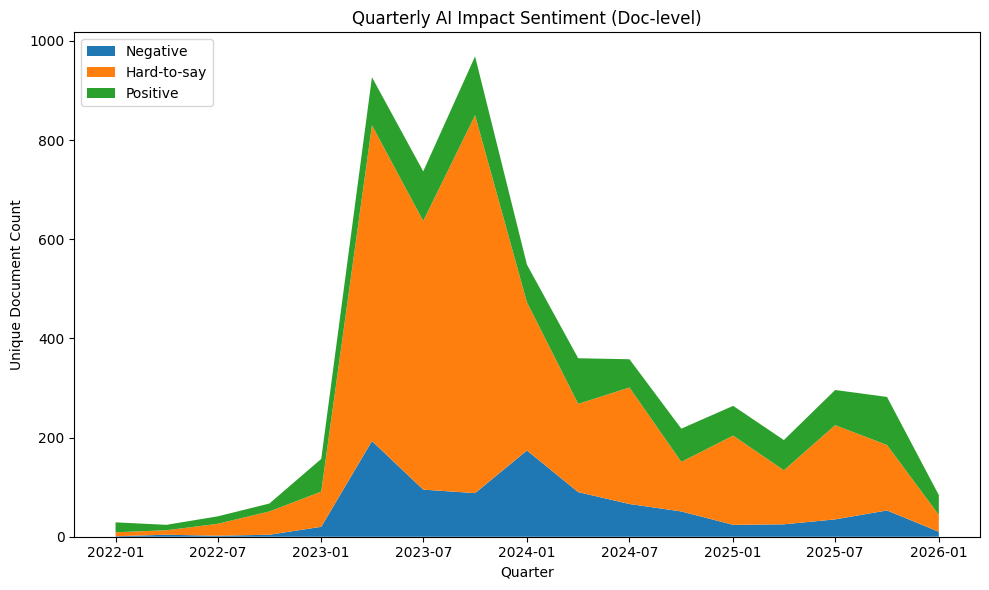

In [59]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

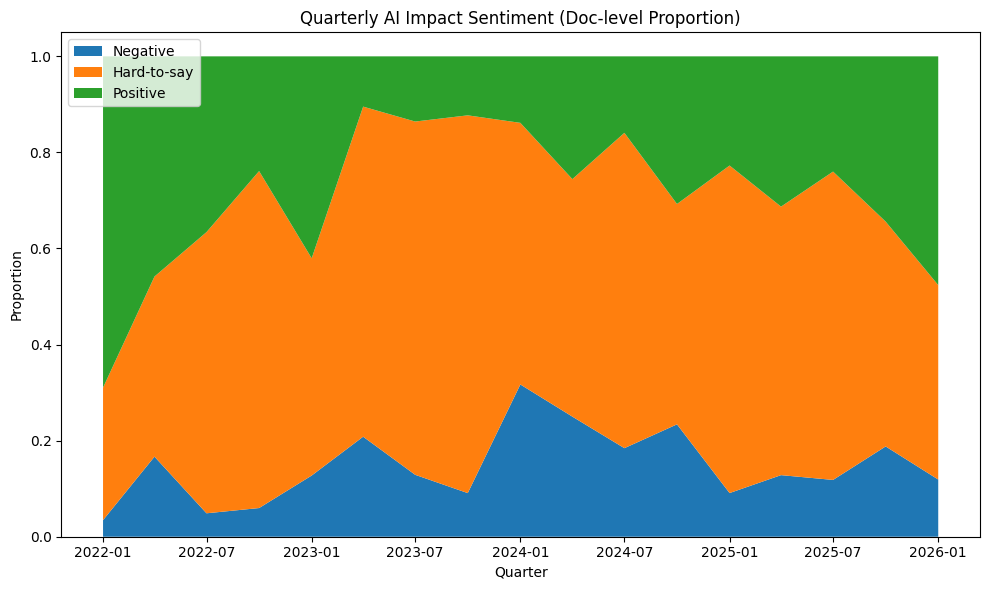

In [60]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()